In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [12]:
def display_image_grayscale(im):
  plt.imshow(im, cmap='gray', vmin=0, vmax=255)
  plt.axis('off')
  plt.show()

def display_image_color(im):
  plt.imshow(im)
  plt.axis('off')
  plt.show()


In [13]:
@njit
def _apply_kernel(im_padded, kernel, padding_size):
    N, M = im_padded.shape
    im_filtered = np.zeros_like(im_padded)

    for i in range(padding_size, N - padding_size):
        for j in range(padding_size, M - padding_size):
            # Explicit slicing for Numba compatibility
            im_window = im_padded[i-padding_size : i+padding_size+1, j-padding_size : j+padding_size+1]
            newPixel = np.sum(im_window * kernel)
            im_filtered[i, j] = newPixel
    return im_filtered

def convolution(im, kernel):
    L = len(kernel)
    padding_size = (L - 1) // 2
    im_padded = np.pad(im, pad_width=padding_size, mode='edge').astype(np.float32)
    im_filtered = _apply_kernel(im_padded, kernel, padding_size)
    im_filtered = im_filtered[padding_size: -padding_size, padding_size: -padding_size]
    return np.clip(im_filtered, 0, 255).astype(np.uint8)

def image_filter(im, kernel):
    if len(kernel) % 2 == 0 or len(kernel) <= 0:
        print("Kernel size must be an odd integer")
        return None

    if len(im.shape) == 3: # RGB/BGR images
        channels = [convolution(im[:, :, i], kernel) for i in range(3)]
        return np.dstack(channels)
    else:
        return convolution(im, kernel)

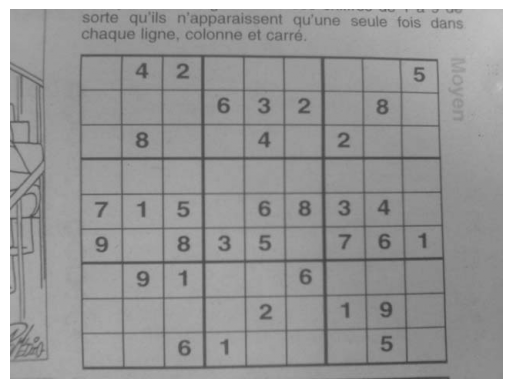

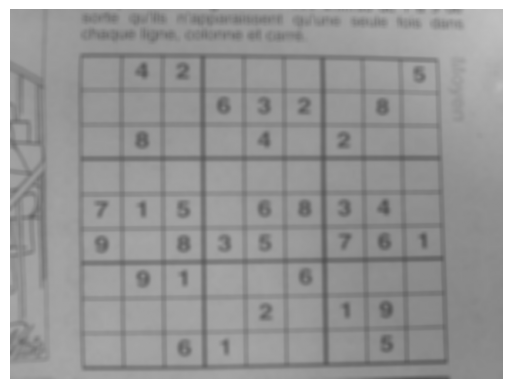

In [14]:
# Create a kernel which is a L by L array where each value is 1/(L^2)
image = cv2.imread("image10.jpg", cv2.IMREAD_GRAYSCALE)
L = 7
kernel = np.ones((L, L)) / (L**2)

blurred_image = image_filter(image, kernel)
display_image_grayscale(image)
display_image_grayscale(blurred_image)